# Rung 4, Sessions 7 and 8

**Session 7 — Ncrit: the knob you didn't know you were turning**
**Session 8 — Where does XFOIL think transition happens?**

These are the two experiments the methods document lists as the obvious next steps.
Session 7 tests the largest unexamined assumption in the study. Session 8 opens up
the thing Finding 3 could not resolve.

Run the setup cell first; everything after it depends on it.

## Setup — run this once

XFOIL is a Debian package, so on Colab (or any Ubuntu machine) this is a one-liner.
No compiling, no wrestling with Fortran.

In [1]:
!apt-get -qq install -y xfoil > /dev/null
!pip -q install aerosandbox > /dev/null
import subprocess
print(subprocess.run(["xfoil"], input="QUIT\n", capture_output=True, text=True).stdout[:200])


  XFOIL Version 6.99
  Copyright (C) 2000   Mark Drela, Harold Youngren

  This software comes with ABSOLUTELY NO WARRANTY,
    subject to the GNU


If you see the XFOIL banner with `Version 6.99`, you are ready.

### The driver

This is the same function the study used, with one addition: it now also returns
**where XFOIL thinks transition happened**, which is what Session 8 needs.

Three things in here are not obvious and all three were learned the hard way:

- `PLOP` / `G F` turns off graphics. Without it XFOIL aborts the moment it tries
  to open a plot window, which it cannot do on a machine with no screen.
- One angle of attack per subprocess. XFOIL run as a continuous sweep carries state
  from point to point, so one bad solve poisons everything after it.
- **The convergence check.** XFOIL prints a lift and a drag whether or not it
  converged. If it burns through its iteration limit with the residual still large,
  it reports the last value it happened to be holding — a number that depends on how
  many iterations you allowed, which is not a result. `strict=True` throws those away.

In [2]:
import subprocess, re
import numpy as np

_RMS = re.compile(r"^\s*(\d+)\s+rms:\s*([-\d.E+]+)", re.M)
_RES = re.compile(r"a =\s*([-\d.]+)\s+CL =\s*([-\d.]+).*?CD =\s*([\d.]+)", re.S)
_SID = re.compile(r"Side\s+(\d)\s+(free|forced)\s+transition at x/c =\s*([\d.]+)")

def xfoil(dat, alpha, Re, ncrit=9, xtr=None, iters=300, timeout=30, strict=True):
    """Run one XFOIL point.

    dat    path to a coordinate file
    alpha  angle of attack, degrees
    Re     Reynolds number
    ncrit  amplification factor for the e^N transition model
    xtr    (upper, lower) x/c to FORCE transition; None = let XFOIL decide

    Returns dict(CL, CD, xtr_top, xtr_bot) or None if the solve did not converge.
    """
    vpar = f"N {ncrit}\n" + (f"XTR {xtr[0]} {xtr[1]}\n" if xtr else "")
    cmds = (f"PLOP\nG F\n\nLOAD {dat}\nAF\nOPER\nVPAR\n{vpar}\n"
            f"VISC {Re}\nITER {iters}\nALFA {alpha}\n\nQUIT\n")
    try:
        out = subprocess.run(["xfoil"], input=cmds, capture_output=True,
                             text=True, timeout=timeout).stdout
    except subprocess.TimeoutExpired:
        return None

    res = _RES.findall(out)
    its = _RMS.findall(out)
    sid = _SID.findall(out)
    if not res or not its or not sid:
        return None

    if strict:
        n, rms = int(its[-1][0]), float(its[-1][1])
        if n >= iters or abs(rms) > 1e-4:
            return None          # never converged - the answer depends on `iters`

    top = [s for s in sid if s[0] == "1"][-1]
    bot = [s for s in sid if s[0] == "2"][-1]
    return dict(CL=float(res[-1][1]), CD=float(res[-1][2]),
                xtr_top=float(top[2]), xtr_bot=float(bot[2]))

print("driver ready")

driver ready


### Coordinates

Repanelled to 120 points per surface. This is not cosmetic: the stock 97-panel
FX 63-137 gave a drag error of **+16.9%** where the 239-panel version gives **-9.5%**.
Same airfoil, same Reynolds number, opposite conclusion.

In [3]:
import aerosandbox as asb

def make_dat(name, path, n_per_side=120):
    a = asb.Airfoil(name).repanel(n_points_per_side=n_per_side)
    with open(path, "w") as f:
        f.write(name.upper() + "\n")
        for x, y in a.coordinates:
            f.write(f"{x:.6f} {y:.6f}\n")
    return path

DAT = {
    "E387":      make_dat("e387",     "e387.dat"),
    "FX 63-137": make_dat("fx63137",  "fx63137.dat"),
    "SD2030":    make_dat("sd2030",   "sd2030.dat"),
}

for name, path in DAT.items():
    r = xfoil(path, 4.0, 200000)
    print(f"{name:<11} CL {r['CL']:.4f}   CD {r['CD']:.5f}   transition at x/c {r['xtr_top']:.3f}")

E387        CL 0.8381   CD 0.01231   transition at x/c 0.611
FX 63-137   CL 1.3169   CD 0.01519   transition at x/c 0.593


SD2030      CL 0.7366   CD 0.00958   transition at x/c 0.685


---

# Session 7 — Ncrit

## 7.1  What the number actually is

A laminar boundary layer does not flip to turbulent at a point. Small disturbances
in it — Tollmien-Schlichting waves — get amplified as they travel downstream. The
e^N method says: track how much the most-amplified disturbance has grown, and call
it transition when the growth factor reaches e^N.

`Ncrit` is that N. At N = 9 the disturbance has grown by e^9, about **8,100 times**
its original size. That is the only thing the number means.

What sets it is how big the disturbances were to begin with — that is, how turbulent
the oncoming air is. A quiet tunnel starts with tiny disturbances, so they need more
amplification to reach the size that trips the boundary layer, so N is large. A noisy
tunnel needs less. Drela's rough guide:

| environment | Ncrit |
|---|---|
| sailplane | 12–14 |
| clean wind tunnel | 10–12 |
| average wind tunnel | **9** |
| dirty wind tunnel | 4–8 |

**9 is a default, not a measurement.** The entire study used it without checking.

## 7.2  What UIUC actually says

Volume 1, section 2.1, describing the tunnel:

> "The turbulence intensity has been measured to be **less than 0.1%**."

That is an upper bound and nothing more. Mack's correlation converts turbulence
intensity to an amplification factor:

$$N_{crit} = -8.43 - 2.4 \ln(Tu)$$

Run it and see what "less than 0.1%" permits.

In [4]:
import math

print("Mack's correlation:  Ncrit = -8.43 - 2.4 ln(Tu)\n")
print(f"{'turbulence intensity':>22}{'Ncrit':>10}")
for tu in (0.001, 0.0007, 0.0005, 0.0003, 0.0002, 0.0001):
    print(f"{tu*100:>21.2f}%{-8.43 - 2.4*math.log(tu):>10.1f}")

print("\nUIUC states Tu < 0.1%, so Ncrit >= 8.1 -- with no stated upper bound.")

Mack's correlation:  Ncrit = -8.43 - 2.4 ln(Tu)

  turbulence intensity     Ncrit
                 0.10%       8.1
                 0.07%       9.0
                 0.05%       9.8
                 0.03%      11.0
                 0.02%      12.0
                 0.01%      13.7

UIUC states Tu < 0.1%, so Ncrit >= 8.1 -- with no stated upper bound.


So the tunnel's own documentation permits anything from about 8 upward.
If the real turbulence intensity is 0.02% — entirely plausible for a tunnel with a
honeycomb and four anti-turbulence screens — the right value is 12.

**Ncrit = 9 is inside the permitted range. So is 13. Nothing in the source picks between them.**

## 7.3  The control experiment — run this before the real one

Here is the reason this experiment is worth doing at all, and the reason you can
trust its answer.

`XTR` forces transition at a fixed station. It bypasses the e^N calculation entirely.
So the **tripped** case should be completely independent of Ncrit — if you change
Ncrit and the tripped drag moves, something in your setup is wrong.

That is a control: a prediction your method makes about itself, which you check
before you trust anything else it says. Run it.

In [5]:
print("CONTROL: tripped drag must not depend on Ncrit\n")
print(f"{'Ncrit':>6}{'E387 tripped Cd':>18}{'SD2030 tripped Cd':>20}")
for nc in (7, 9, 11, 13):
    e387 = np.mean([xfoil(DAT["E387"],   al, 100000, ncrit=nc, xtr=(0.02, 0.05))["CD"]
                    for al in (0., 2., 4., 6., 8.)])
    sd   = np.mean([xfoil(DAT["SD2030"], al, 100000, ncrit=nc, xtr=(0.02, 0.05))["CD"]
                    for al in (0., 2., 4., 6., 8.)])
    print(f"{nc:>6}{e387:>18.5f}{sd:>20.5f}")

CONTROL: tripped drag must not depend on Ncrit

 Ncrit   E387 tripped Cd   SD2030 tripped Cd


     7           0.02225             0.02132


     9           0.02225             0.02132


    11           0.02225             0.02132


    13           0.02225             0.02132


Expected: identical to five significant figures down each column. If yours move,
stop and find out why before going on.

(When I ran this the FX 63-137 *did* appear to move — because at high Ncrit some of
its angles stopped converging and dropped out of the average, changing which points
were being averaged rather than their values. That is worth knowing: a number that
shifts because your sample changed looks exactly like a number that shifted because
the physics changed.)

## 7.4  The sweep

Now the real thing. Same five angles, same Reynolds number, four values of Ncrit,
both configurations. The experimental values are constants here, taken from the
Volume 4 files.

In [6]:
EXP_TRIP_EFFECT = {"E387": -11.4, "FX 63-137": -25.9, "SD2030": -3.0}   # percent, Re=1e5
ALPHAS = (0., 2., 4., 6., 8.)

print("NCRIT SENSITIVITY  --  Re = 100,000\n")
print(f"{'airfoil':<11}{'Ncrit':>6}{'clean Cd':>11}{'tripped Cd':>12}"
      f"{'XFOIL trip eff':>16}{'measured':>11}{'sign':>8}")

results = {}
for name, dat in DAT.items():
    results[name] = {}
    for nc in (7, 9, 11, 13):
        c = [xfoil(dat, a, 100000, ncrit=nc) for a in ALPHAS]
        t = [xfoil(dat, a, 100000, ncrit=nc, xtr=(0.02, 0.05)) for a in ALPHAS]
        keep = [i for i in range(len(ALPHAS)) if c[i] and t[i]]
        if not keep:
            continue
        cc = np.array([c[i]["CD"] for i in keep])
        tt = np.array([t[i]["CD"] for i in keep])
        eff = 100*np.mean((tt - cc)/cc)
        results[name][nc] = eff
        agree = "same" if np.sign(eff) == np.sign(EXP_TRIP_EFFECT[name]) else "OPPOSITE"
        print(f"{name:<11}{nc:>6}{cc.mean():>11.5f}{tt.mean():>12.5f}"
              f"{eff:>+15.1f}%{EXP_TRIP_EFFECT[name]:>+10.1f}%  {agree:<8}")

NCRIT SENSITIVITY  --  Re = 100,000

airfoil     Ncrit   clean Cd  tripped Cd  XFOIL trip eff   measured    sign


E387            7    0.01857     0.02225          +22.1%     -11.4%  OPPOSITE


E387            9    0.02041     0.02225           +9.9%     -11.4%  OPPOSITE


E387           11    0.02388     0.02225           -6.5%     -11.4%  same    


E387           13    0.03296     0.02225          -29.3%     -11.4%  same    


...

FX 63-137      13    0.04830     0.02945          -29.1%     -25.9%  same    


SD2030          7    0.01819     0.02132          +19.9%      -3.0%  OPPOSITE


SD2030          9    0.01945     0.02132          +12.4%      -3.0%  OPPOSITE


SD2030         11    0.02109     0.02132           +4.2%      -3.0%  OPPOSITE


SD2030         13    0.02300     0.02132           -3.1%      -3.0%  same    


### Seeing it move

The table is the evidence; the picture is what makes it obvious. Plot the predicted
trip effect against Ncrit with the measured value as a flat line, and the question
becomes visual: **where does each curve cross the measurement?** If a curve crosses
inside the range the tunnel documentation permits, Ncrit can be chosen to make XFOIL
agree — which means the agreement was never evidence of anything.

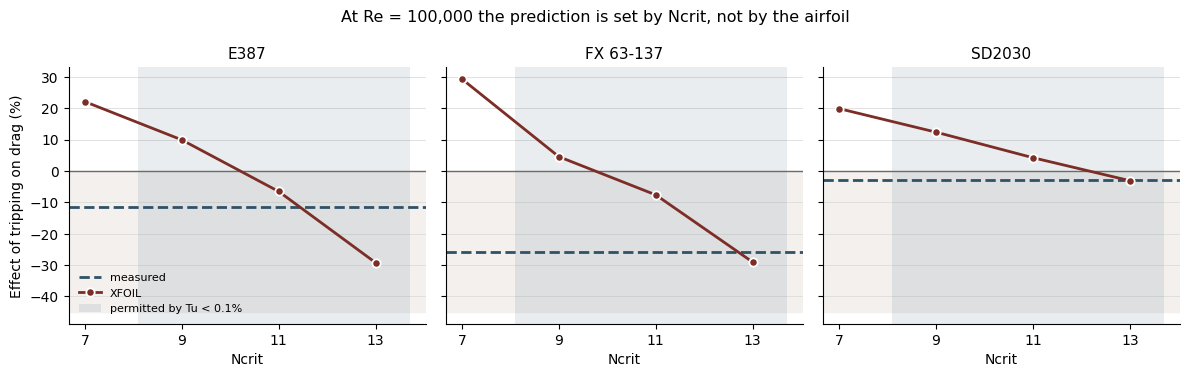

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
NC = [7, 9, 11, 13]

for ax, (name, r) in zip(axes, results.items()):
    y = [r[n] for n in NC if n in r]
    x = [n for n in NC if n in r]
    ax.axhspan(-45, 0, color="#f3f0ee", zorder=0)
    ax.axhline(0, color="#6b6b6b", lw=1)
    ax.axhline(EXP_TRIP_EFFECT[name], color="#2E5266", lw=2, ls="--",
               label="measured")
    ax.plot(x, y, color="#7B2D26", lw=2, marker="o", ms=6, mec="white", mew=1.3,
            label="XFOIL")
    ax.axvspan(8.1, 13.7, color="#2E5266", alpha=0.10, lw=0,
               label="permitted by Tu < 0.1%")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Ncrit")
    ax.set_xticks(NC)
    ax.grid(axis="y", color="#dcdcdc", lw=0.6)
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

axes[0].set_ylabel("Effect of tripping on drag (%)")
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
fig.suptitle("At Re = 100,000 the prediction is set by Ncrit, not by the airfoil",
             fontsize=11.5)
plt.tight_layout()
plt.savefig("ncrit_sweep.png", dpi=130)
plt.show()

Three curves, three airfoils, all sloping the same way and all crossing
the measurement somewhere between Ncrit 9 and 13 — inside the shaded band that the
tunnel's own turbulence figure permits. The airfoil barely changes the picture. Ncrit
changes everything.

That is what it looks like when a model has a knob big enough to reach the answer.

## 7.5  What you just found

Read the E387 column down.

The tripped drag never moves. The clean drag nearly doubles. And the predicted trip
effect goes from **+22% to -29%** — it crosses zero — while the measurement sits at
-11.4% the whole time.

**At Ncrit = 13, XFOIL agrees with the experiment. At Ncrit = 7 it contradicts it.
Both values are inside what the tunnel's stated turbulence intensity permits.**

This does real damage to Finding 1 of the methods document. That finding said XFOIL
over-states the cost of tripping at Re = 100,000. What is actually true is narrower:

> *At Ncrit = 9*, XFOIL over-states the cost of tripping at Re = 100,000.

At Re = 100,000 XFOIL is not making a prediction about the airfoil. It is reporting
your choice of Ncrit back to you, amplified. The airfoil barely gets a vote.

## 7.6  What survives, and why it is the better result

Go back to the control. **The tripped configuration has no free parameter.** Forcing
transition bypasses the e^N model, so Ncrit cannot be tuned to improve or worsen the
tripped comparison. Whatever error XFOIL has there is an error you cannot argue with.

From Table 2 of the methods document, tripped-configuration drag error at Re = 100,000:
E387 **+4.3%**, SD2030 **+23.0%**, FX 63-137 **-18.5%**. At Re = 350,000: within 2%
on all three.

That comparison was sitting in the study the whole time, and it is the only part of
it that no one can tune. The reorganised claim is:

> XFOIL's transition model is the dominant source of error at low Reynolds number.
> With transition forced, XFOIL predicts drag to within a few percent at Re ≥ 350,000
> and to within 5–25% at Re = 100,000. With transition free, the low-Reynolds-number
> answer is controlled by Ncrit rather than by the airfoil, and cannot be validated
> against this data without an independent measurement of the tunnel's turbulence level.

That is a smaller claim than the one in the document. It is also one that cannot be
overturned by a parameter someone else picks differently.

**Exercise.** Find the Ncrit that best matches the *clean* measured drag at each
Reynolds number for each airfoil. Then ask whether one value works everywhere, or
whether you need a different Ncrit at each Reynolds number — because if you do, Ncrit
is not modelling tunnel turbulence any more, it is absorbing whatever XFOIL got wrong.

---

# Session 8 — Where does XFOIL think transition happens?

## 8.1  Getting the number out

Finding 3 of the methods document could not settle why XFOIL over-states the trip
penalty — whether the error is in the clean case or the tripped one, and it differs
by airfoil. The missing quantity is the transition location.

XFOIL has been printing it all along:

```
 Side 1  free  transition at x/c =  0.5672   62
 Side 2 forced transition at x/c =  1.0000  114
```

Side 1 is the upper surface, side 2 the lower. The driver already captures both as
`xtr_top` and `xtr_bot`. Map them.

In [8]:
print("XFOIL clean transition locations, averaged over alpha = 0 to 8 deg\n")
print(f"{'airfoil':<11}{'Re':>9}{'upper x/c':>12}{'lower x/c':>12}"
      f"{'trip moves upper':>19}")
XTR = {}
for name, dat in DAT.items():
    XTR[name] = {}
    for Re in (100000, 200000, 350000, 500000):
        v = [xfoil(dat, a, Re) for a in ALPHAS]
        v = [x for x in v if x]
        if not v:
            continue
        top = np.mean([x["xtr_top"] for x in v])
        bot = np.mean([x["xtr_bot"] for x in v])
        XTR[name][Re] = (top, bot)
        print(f"{name:<11}{Re:>9}{top:>12.3f}{bot:>12.3f}{top-0.02:>18.3f}c")

XFOIL clean transition locations, averaged over alpha = 0 to 8 deg

airfoil           Re   upper x/c   lower x/c   trip moves upper


E387          100000       0.567       1.000             0.547c


E387          200000       0.490       1.000             0.470c


E387          350000       0.385       1.000             0.365c


E387          500000       0.356       1.000             0.336c


...

FX 63-137     500000       0.455       0.711             0.435c


SD2030        100000       0.624       1.000             0.604c


SD2030        200000       0.551       1.000             0.531c


SD2030        350000       0.492       0.998             0.472c


SD2030        500000       0.451       0.991             0.431c


## 8.2  The thing to notice

Look at the lower-surface column for the E387 and the SD2030.

**1.000.** At every Reynolds number. XFOIL is saying the lower-surface boundary layer
stays laminar all the way to the trailing edge — no disturbance anywhere on that
surface ever reaches e^9.

Now think about what the trip does to that. The tripped case forces transition at 5%
chord on the lower surface. So in XFOIL's world the trip converts a **fully laminar**
lower surface into a **fully turbulent** one. That is the largest possible change you
could make to that surface, and turbulent skin friction is several times laminar.

There is a good chance most of XFOIL's over-predicted trip penalty is coming from the
lower surface, not the upper one. Test it: trip only the upper surface, leave the
lower one free, and see how much of the effect survives.

In [9]:
print("Where does the predicted trip penalty come from?  Re = 100,000\n")
print(f"{'airfoil':<11}{'both surfaces':>15}{'upper only':>13}{'lower only':>13}"
      f"{'measured':>11}")
for name, dat in DAT.items():
    raw = [xfoil(dat, a, 100000) for a in ALPHAS]
    def eff(xtr):
        t = [xfoil(dat, a, 100000, xtr=xtr) for a in ALPHAS]
        keep = [i for i in range(len(ALPHAS)) if t[i] and raw[i]]
        cc = np.array([raw[i]["CD"] for i in keep])
        tt = np.array([t[i]["CD"] for i in keep])
        return 100*np.mean((tt - cc)/cc)
    both  = eff((0.02, 0.05))
    upper = eff((0.02, 1.00))
    lower = eff((1.00, 0.05))
    print(f"{name:<11}{both:>+14.1f}%{upper:>+12.1f}%{lower:>+12.1f}%"
          f"{EXP_TRIP_EFFECT[name]:>+10.1f}%")

Where does the predicted trip penalty come from?  Re = 100,000

airfoil      both surfaces   upper only   lower only   measured


E387                 +9.9%        -0.9%       +10.6%     -11.4%


FX 63-137            +4.6%        +0.5%        +2.0%     -25.9%


SD2030              +12.4%        +0.1%       +12.5%      -3.0%


If upper-only is a small fraction of both-surfaces, the lower surface is where
XFOIL's trip penalty is manufactured — and the physical question becomes whether a
real lower surface at Re = 100,000 with an adverse pressure gradient genuinely stays
laminar to the trailing edge, or whether XFOIL is missing a separation bubble there.

The honest answer is that this data cannot tell you. The Volume 4 files record lift,
drag and moment — not transition. You would need:

- **oil-flow visualisation**, which UIUC published for some airfoils in Volumes 1 and 2;
  it shows the laminar separation line, the transition region and reattachment
  directly as a photograph of the surface
- or a stethoscope traverse, or surface hot films, neither of which is in this dataset

So Session 8 does not close Finding 3. What it does is turn "the mechanism differs by
airfoil and we don't know why" into a specific, falsifiable statement — *XFOIL's trip
penalty at low Reynolds number is dominated by the lower surface, where it predicts
fully laminar flow to the trailing edge* — which is the form a question has to be in
before an experiment can answer it.

## 8.3  Connecting back to a wing

The `trip moves upper` column is the useful one for design. At Re = 100,000 the trip
drags transition forward by more than half a chord. At Re = 500,000 it is a third of
a chord. That shrinking is the whole story of this project in one column: as Reynolds
number rises, natural transition moves forward on its own, the laminar run you are
protecting gets shorter, and forcing transition costs less because there was less
laminar flow left to lose.

An FSAE element at Re ≈ 250,000 sits between rows two and three. Roughly 45% of the
chord is laminar in XFOIL's estimate, and that laminar run is what a bug strike, a
paint ridge, or a badly placed sticker destroys.

**Exercise.** Re-run the `trip moves upper` column at Ncrit = 12 instead of 9. Session 7
says the clean drag changes a lot. Does the transition location change by a lot too,
or does the drag change come from somewhere else? The answer tells you whether Ncrit
is moving transition or changing the bubble.

### One more, because it closes the loop

Session 7 said the clean drag is Ncrit-sensitive. Session 8 said the trip penalty is
manufactured on the lower surface. Put them together: as Ncrit rises, the upper-surface
bubble grows, so tripping the upper surface should start to *save* drag rather than
cost nothing. Run the upper-only trip against Ncrit and watch.

In [10]:
print("E387, Re = 100,000 -- upper-surface trip only, against Ncrit\n")
print(f"{'Ncrit':>6}{'clean Cd':>11}{'upper-tripped Cd':>19}{'effect':>10}")
for nc in (7, 9, 11, 13):
    c = np.array([xfoil(DAT["E387"], a, 100000, ncrit=nc)["CD"] for a in ALPHAS])
    t = np.array([xfoil(DAT["E387"], a, 100000, ncrit=nc,
                        xtr=(0.02, 1.00))["CD"] for a in ALPHAS])
    print(f"{nc:>6}{c.mean():>11.5f}{t.mean():>19.5f}"
          f"{100*np.mean((t-c)/c):>+9.1f}%")

E387, Re = 100,000 -- upper-surface trip only, against Ncrit

 Ncrit   clean Cd   upper-tripped Cd    effect


     7    0.01857            0.02020     +9.9%


     9    0.02041            0.02020     -0.9%


    11    0.02388            0.02020    -15.6%


    13    0.03296            0.02020    -36.0%


If the upper-only effect goes negative as Ncrit rises, the story holds
together: at high Ncrit XFOIL predicts a large laminar separation bubble on the upper
surface, and killing it with a trip is worth more than the turbulent skin friction it
costs. That is precisely the physics the wind tunnel is reporting when it measures a
drag *reduction* from tripping at Re = 100,000.

Which would mean XFOIL at Ncrit = 9 is not wrong about the mechanism. It is wrong about
how big the bubble is — and that is a much more specific, much more fixable
criticism than 'XFOIL over-states the trip penalty.'

---

## What to do with these two sessions

Session 7 is a retraction and a replacement. Finding 1 as written in the methods
document is conditional on a parameter nobody measured, and the document needs to say
so. What replaces it — the parameter-free tripped comparison — is a smaller claim that
is much harder to attack.

Session 8 is a lead, not a conclusion. It converts an open question into a testable
one and identifies exactly which measurement would close it.

Both are worth writing up in the same voice as the rest: what was assumed, what was
tested, what changed, what survived.